In [1]:
import os
import numpy as np
import scipy.io as sio
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
from matplotlib.colors import ListedColormap
import seaborn as sns
from tabulate import tabulate
import tifffile
import glob

In [2]:
BASE_DIR   = Path.cwd()
DATA_DIR   = os.path.join(BASE_DIR, "datas")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "week1b")

In [3]:
search_pat = os.path.join(DATA_DIR, "**", "*-SPECTRAL_IMAGE.TIF")
tif_files = sorted(glob.glob(search_pat, recursive=True))

if not tif_files:
    print(f"[!] No *-SPECTRAL_IMAGE.TIF files found in {DATA_DIR}")

In [4]:
print(f"Found {len(tif_files)} EnMAP images:\n")
for fp in tif_files:
    size_mb = os.path.getsize(fp) / 1024**2
    print(f"  • {os.path.basename(os.path.dirname(fp))[:60]}  ({size_mb:.0f} MB)")

Found 7 EnMAP images:

  • ENMAP01-____L2A-DT0000044635_20230923T050553Z_016_V010502_20  (346 MB)
  • ENMAP01-____L2A-DT0000044635_20230923T050607Z_019_V010502_20  (348 MB)
  • ENMAP01-____L2A-DT0000051947_20231128T051615Z_009_V010502_20  (351 MB)
  • ENMAP01-____L2A-DT0000058175_20240117T051315Z_001_V010502_20  (346 MB)
  • ENMAP01-____L2A-DT0000058175_20240117T051328Z_004_V010502_20  (350 MB)
  • ENMAP01-____L2A-DT0000060162_20240205T050519Z_014_V010502_20  (356 MB)
  • ENMAP01-____L2A-DT0000060162_20240205T050524Z_015_V010502_20  (355 MB)


In [5]:
def plot_band_correlation(data, filename):
    """Inter-band Pearson correlation heatmap (sampled pixels)."""
    H, W, B = data.shape
    flat = data.reshape(-1, B)
    flat = flat[pixel_valid_mask(flat)]
    pix = fill_missing_with_band_means(sample_pixels(flat, SAMPLE_PIXELS))
    corr = np.corrcoef(pix.T)   # (B, B)

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto',
                   interpolation='nearest')
    ax.set_xlabel("Band Index")
    ax.set_ylabel("Band Index")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson Correlation")
    plt.show()

In [7]:
def load_enmap_tif(filepath):
    """
    Load an EnMAP SPECTRAL_IMAGE.TIF and return (H, W, B) float32 array.
    Handles both (B,H,W) and (H,W,B) layouts.
    EnMAP nodata fill = -32768 (int16 origin). Replace with NaN.
    """
    data = tifffile.imread(filepath).astype(np.float32)
    # EnMAP ships as (Bands, H, W)
    if data.ndim == 3 and data.shape[0] > 100 and data.shape[1] > 500:
        data = data.transpose(1, 2, 0)   # → (H, W, B)
    # EnMAP nodata: -32768 (int16 min) or any value <= -32768 (making them nan float)
    data[data <= -32768] = np.nan
    return data

In [45]:
first_fp = tif_files[2]
print("  Loading TIF...")
data_raw = load_enmap_tif(first_fp)
H, W, B = data_raw.shape
print(f"  Shape: {H} × {W} × {B}  |  dtype: {data_raw.dtype}")
print(f"  Memory: {data_raw.nbytes / 1024**3:.2f} GB")

  Loading TIF...
  Shape: 1200 × 1260 × 224  |  dtype: float32
  Memory: 1.26 GB


In [46]:
for b in range(data_raw.shape[2]):
    nan_ratio = np.isnan(data_raw[:, :, b]).mean()
    if nan_ratio > 0.5:
        print(f"Band {b}: {nan_ratio*100:.2f}% NaN")

Band 130: 100.00% NaN
Band 131: 100.00% NaN
Band 132: 100.00% NaN
Band 133: 100.00% NaN
Band 134: 100.00% NaN


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3536\4184224363.py:7: RuntimeWarning: Mean of empty slice
  band_means = np.nanmean(flat, axis=0)


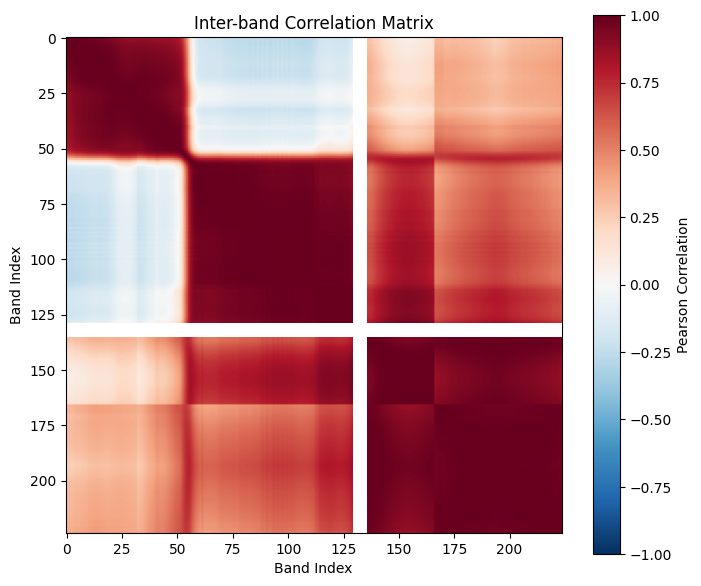

In [47]:
# Plotting the Pearson Correlation matrix (No Cleaning - raw data)

# reshape
flat = data_raw.reshape(-1, B)

# replace NaNs with band-wise mean
band_means = np.nanmean(flat, axis=0)
inds = np.where(np.isnan(flat))
flat[inds] = np.take(band_means, inds[1])

# compute correlation
corr = np.corrcoef(flat.T)

# plot
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Pearson Correlation')
plt.xlabel('Band Index')
plt.ylabel('Band Index')
plt.title('Inter-band Correlation Matrix')
plt.show()

In [48]:
# Cheacking for bad bands
# condition 1: all NaN
# condition 2: zero variance

# reshape to (pixels, bands)
pixels = data_raw.reshape(-1, data_raw.shape[-1])

all_nan = np.all(np.isnan(pixels), axis=0)
std = np.nanstd(pixels, axis=0)
zero_std = std < 1e-6
# combine
bad_bands = np.where(all_nan | zero_std)[0]
print("Bad bands:", bad_bands)
print("Number of bad bands:", len(bad_bands))

Bad bands: [130 131 132 133 134]
Number of bad bands: 5


C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


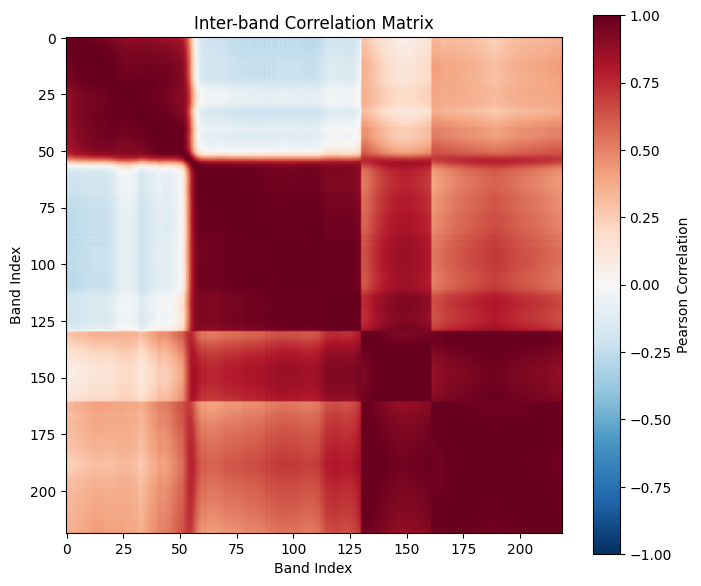

In [49]:
# Plotting the Pearson Correlation matrix (Clean data - removnig bad bands)


# reshape
flat = data_raw.reshape(-1, B)

# remove bands with near-zero variance
std = np.std(flat, axis=0)
valid_bands = std > 1e-6   # threshold

flat = flat[:, valid_bands]

# now correlation
corr = np.corrcoef(flat.T)

# replace NaNs with band-wise mean
band_means = np.nanmean(flat, axis=0)
inds = np.where(np.isnan(flat))
flat[inds] = np.take(band_means, inds[1])

# plot
plt.figure(figsize=(8, 7))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Pearson Correlation')
plt.xlabel('Band Index')
plt.ylabel('Band Index')
plt.title('Inter-band Correlation Matrix')
plt.show()

In [50]:
# Removing bands from data

data = data_raw[:, :, valid_bands]
data.shape

(1200, 1260, 219)

In [51]:
DATA_DIR = os.path.join(BASE_DIR, "datas")
PROCESSED_DIR = os.path.join(BASE_DIR, "processed_data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "week2b")

In [52]:
def extract_sampled_patches(data, patch_size, num_samples, seed=42, valid_mask=None):
    """
    Extract randomly sampled spatial patches with zero-padding.
    data: (H, W, B)
    """
    H, W, B = data.shape
    margin = patch_size // 2
    
    # Zero-pad the spatial dimensions
    padded = np.pad(
        data,
        ((margin, margin), (margin, margin), (0, 0)),
        mode='constant',
        constant_values=0
    )
    
    rng = np.random.default_rng(seed)
    if valid_mask is None:
        valid_mask = np.ones((H, W), dtype=bool)

    rows, cols = np.where(valid_mask)
    if len(rows) == 0:
        raise ValueError("No valid center pixels available for patch sampling.")

    sample_size = min(num_samples, len(rows))
    sample_idx = rng.choice(len(rows), size=sample_size, replace=False)
    rows = rows[sample_idx]
    cols = cols[sample_idx]
    
    # Pre-allocate array for PyTorch: (N, Bands, H, W)
    patches = np.zeros((sample_size, B, patch_size, patch_size), dtype=np.float32)
    coords = np.zeros((sample_size, 2), dtype=np.int32)
    
    for i in range(sample_size):
        r, c = rows[i], cols[i]
        # Padded array is shifted by margin, so padded[r:r+ps] corresponds to centering at original r
        patch = padded[r:r+patch_size, c:c+patch_size, :]
        patches[i] = patch.transpose(2, 0, 1)  # (B, 7, 7)
        coords[i] = [r, c]
        
    return patches, coords

In [53]:

def normalize_bands(data: np.ndarray, method: str = "zscore") -> np.ndarray:
    H, W, B = data.shape
    normalized = np.zeros_like(data, dtype=np.float64)
    
    for b in range(B):
        band = data[:, :, b].astype(np.float64, copy=False)
        finite_mask = np.isfinite(band)

        if not finite_mask.any():
            normalized[:, :, b] = np.nan
            continue

        valid = band[finite_mask]
        norm_band = np.full_like(band, np.nan, dtype=np.float64)

        if method == "zscore":
            mean = valid.mean()
            std = valid.std()
            if std > 1e-10:
                norm_band[finite_mask] = (valid - mean) / std
            else:
                norm_band[finite_mask] = valid - mean
        elif method == "minmax":
            bmin, bmax = valid.min(), valid.max()
            if bmax - bmin > 1e-10:
                norm_band[finite_mask] = (valid - bmin) / (bmax - bmin)
            else:
                norm_band[finite_mask] = 0.0
        else:
            raise ValueError(f"Unknown normalization method: {method}. Use 'zscore' or 'minmax'.")

        normalized[:, :, b] = norm_band
    
    return normalized

In [54]:
# Patch configuration
PATCH_SIZE = 7
SAMPLES_PER_IMAGE = 25000  # 1 image * 25k = 25k total training patches (~1 GB RAM)
RANDOM_SEED = 42

In [55]:

print("="*70)
print(" STARTING ENMAP PREPROCESSING & SAMPLING")
print("="*70)

print(f"  -> Original shape: {data.shape} | dtype: {data.dtype}")

valid_centers = np.isfinite(data).any(axis=2)
complete_centers = np.isfinite(data).all(axis=2)
n_valid = int(valid_centers.sum())
n_complete = int(complete_centers.sum())
print(f"  -> Valid center pixels: {n_valid:,} / {data.shape[0] * data.shape[1]:,}")
print(f"  -> Fully observed centers: {n_complete:,}")
if n_valid == 0:
    print("  -> Skipping scene: no valid pixels after nodata masking.")

# Normalization (Z-score)
print("  -> Normalizing valid pixels (Z-score)...")
data = normalize_bands(data, method="zscore").astype(np.float32)
# After z-score, 0 is the per-band mean, so it is a neutral fill value for nodata.
data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

# Random Sampling
print(f"  -> Sampling up to {SAMPLES_PER_IMAGE:,} patches (7x7) from valid centers...")
patches, _ = extract_sampled_patches(
    data,
    patch_size=PATCH_SIZE,
    num_samples=SAMPLES_PER_IMAGE,
    seed=RANDOM_SEED,
    valid_mask=valid_centers,
)

print(f"Final dataset shape: {patches.shape}")
print(f"Total memory size: {patches.nbytes / 1024**3:.2f} GB")

# Save to disk
out_file = os.path.join(PROCESSED_DIR, "enmap_train_patches_3.npy")
print(f"Saving to: {out_file}")
np.save(out_file, patches)

print("="*70)
print(" ENMAP PREPROCESSING COMPLETE!")
print("="*70)

 STARTING ENMAP PREPROCESSING & SAMPLING
  -> Original shape: (1200, 1260, 219) | dtype: float32
  -> Valid center pixels: 1,512,000 / 1,512,000
  -> Fully observed centers: 1,512,000
  -> Normalizing valid pixels (Z-score)...
  -> Sampling up to 25,000 patches (7x7) from valid centers...
Final dataset shape: (25000, 219, 7, 7)
Total memory size: 1.00 GB
Saving to: E:\SEM_6\Minor Project\processed_data\enmap_train_patches_3.npy
 ENMAP PREPROCESSING COMPLETE!


In [56]:
def plot_value_distribution(data_raw, data, img_label, filename):
    """Histograms: raw reflectance vs z-score normalised values."""
    H, W, B = data_raw.shape
    # Sample random pixels, pick 10 evenly-spaced bands
    flat_raw  = data_raw.reshape(-1, B)
    flat_norm = data.reshape(-1, data.shape[-1])

    valid = ~np.all(np.isnan(flat_raw), axis=1)
    flat_raw  = flat_raw[valid]
    flat_norm = flat_norm[valid]

    sample_raw  = sample_pixels(flat_raw,  3000).ravel()
    sample_norm = sample_pixels(flat_norm, 3000).ravel()
    sample_norm = sample_norm[np.isfinite(sample_norm)]
    sample_norm = sample_norm[sample_norm != 0] 

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{img_label} — Pixel Value Distributions", fontweight='bold', fontsize=13)

    axes[0].hist(sample_raw, bins=100, color='#3cb44b', alpha=0.8, edgecolor='none')
    axes[0].set_xlabel("Reflectance (raw L2A)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Raw pixel values")
    axes[0].grid(True, alpha=0.3, linestyle='--')

    axes[1].hist(sample_norm, bins=100, color='#4363d8', alpha=0.8, edgecolor='none')
    axes[1].set_xlabel("Z-score")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("After Z-score normalisation")
    axes[1].grid(True, alpha=0.3, linestyle='--')

    plt.show()

In [57]:
def sample_pixels(data_2d_or_3d, n, seed=RANDOM_SEED):
    """Randomly sample n pixel rows from a (N, B) or (H*W, B) array."""
    rng = np.random.default_rng(seed)
    if data_2d_or_3d.ndim == 3:
        H, W, B = data_2d_or_3d.shape
        flat = data_2d_or_3d.reshape(-1, B)
    else:
        flat = data_2d_or_3d
    idx = rng.choice(len(flat), min(n, len(flat)), replace=False)
    return flat[idx]

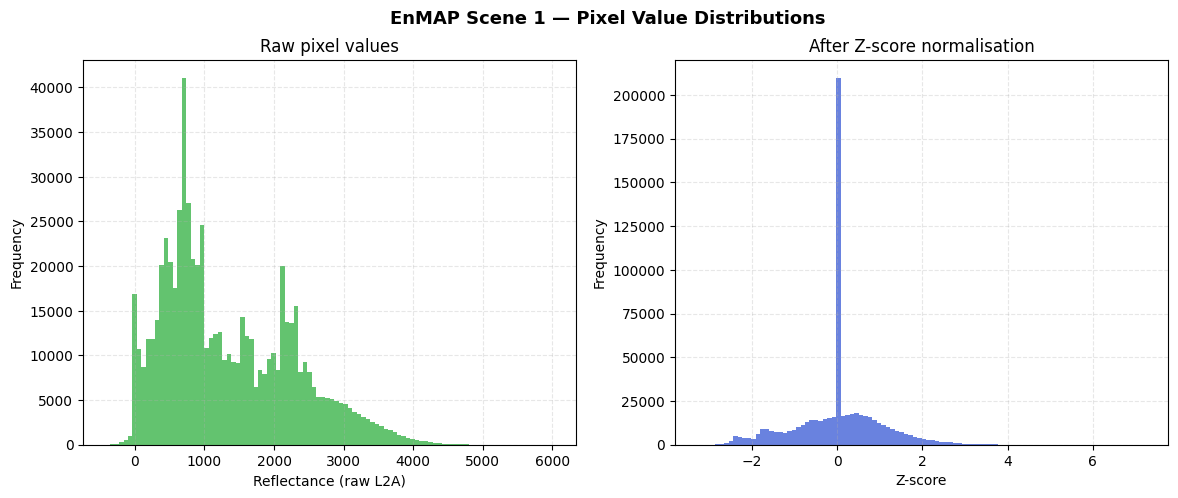

In [58]:
plot_value_distribution(data_raw, data, "EnMAP Scene 1", filename="enmap_value_distribution.png")